<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/ExercicioPratico1.4/An%C3%A1lise_e_Limpeza_de_Dados_de_E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")
np.random.seed(101)

# Gerando dados fictícios de clientes de um e-commerce
n = 200
categorias = ['Eletrônicos', 'Vestuário', 'Casa e Decoração', 'Livros']

dados = {
    'ID_Cliente': np.random.randint(1000, 1050, size=n),
    'Categoria': np.random.choice(categorias, size=n),
    'Valor_Gasto': np.random.normal(loc=250, scale=80, size=n).round(2),
    'Avaliacao_Compra': np.random.choice([1, 2, 3, 4, 5, np.nan], size=n, p=[0.1, 0.1, 0.2, 0.3, 0.2, 0.1]),
    'Idade_Cliente': np.random.randint(18, 65, size=n)
}

df_ecommerce = pd.DataFrame(dados)

# Inserindo algumas linhas duplicadas intencionalmente
df_ecommerce = pd.concat([df_ecommerce, df_ecommerce.iloc[:10]], ignore_index=True)

print("Dataset gerado com sucesso!")
print(f"Total de linhas no dataset: {len(df_ecommerce)}")
df_ecommerce.head()

Dataset gerado com sucesso!
Total de linhas no dataset: 210


,ID_Cliente,Categoria,Valor_Gasto,Avaliacao_Compra,Idade_Cliente
0,1031,Vestuário,236.62,NaN,33
1,1011,Eletrônicos,190.28,4.0,47
2,1017,Eletrônicos,336.59,2.0,35
3,1006,Eletrônicos,307.38,5.0,52
4,1023,Vestuário,170.69,4.0,42


### Tarefa 1: Limpeza e Preparação dos Dados

In [2]:
# 1. Verifique quantas linhas duplicadas existem no DataFrame e remova-as.
print(f"Número inicial de linhas: {len(df_ecommerce)}")
duplicated_rows = df_ecommerce.duplicated().sum()
print(f"Número de linhas duplicadas encontradas: {duplicated_rows}")

df_ecommerce.drop_duplicates(inplace=True)
print(f"Número de linhas após a remoção de duplicatas: {len(df_ecommerce)}")

Número inicial de linhas: 210
Número de linhas duplicadas encontradas: 10
Número de linhas após a remoção de duplicatas: 200


In [3]:
# 2. Identifique quais colunas possuem valores nulos (NaN).
print("Valores nulos por coluna:")
display(df_ecommerce.isnull().sum())

Valores nulos por coluna:


,0
ID_Cliente,0
Categoria,0
Valor_Gasto,0
Avaliacao_Compra,21
Idade_Cliente,0


In [4]:
# 3. Preencha os valores nulos da coluna Avaliacao_Compra com a mediana dessa mesma coluna.
median_avaliacao = df_ecommerce['Avaliacao_Compra'].median()
print(f"Mediana de Avaliacao_Compra: {median_avaliacao}")
df_ecommerce['Avaliacao_Compra'].fillna(median_avaliacao, inplace=True)

print("Valores nulos após o preenchimento da mediana:")
display(df_ecommerce.isnull().sum())

Mediana de Avaliacao_Compra: 4.0
Valores nulos após o preenchimento da mediana:


/tmp/ipykernel_1080/2381721064.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ecommerce['Avaliacao_Compra'].fillna(median_avaliacao, inplace=True)


,0
ID_Cliente,0
Categoria,0
Valor_Gasto,0
Avaliacao_Compra,0
Idade_Cliente,0


### Tarefa 2: Comparação por Categoria (Gráfico de Boxplot com Seaborn)

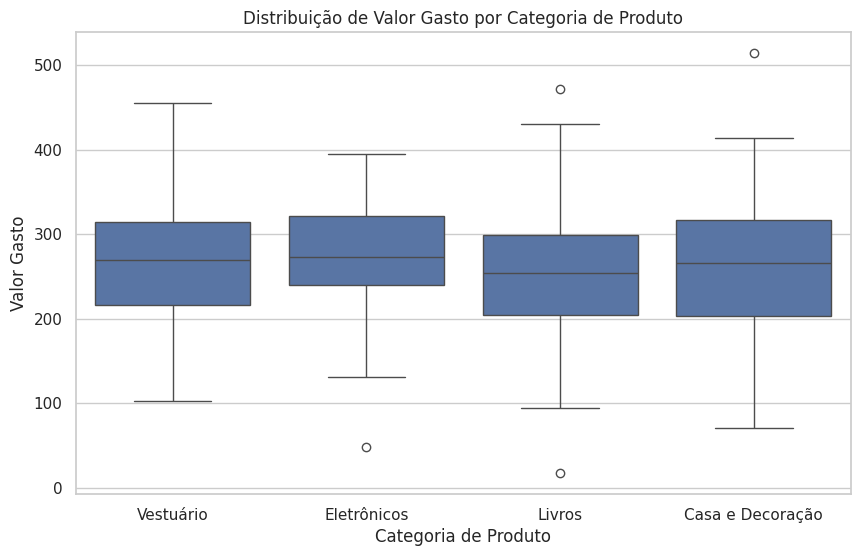

In [5]:
# 1. Crie um gráfico de Boxplot usando a biblioteca ‘seaborn’ (‘sns.boxplot’) para comparar a distribuição de Valor_Gasto entre as diferentes Categorias de produtos.
plt.figure(figsize=(10, 6))
sns.boxplot(x='Categoria', y='Valor_Gasto', data=df_ecommerce)
plt.title('Distribuição de Valor Gasto por Categoria de Produto')
plt.xlabel('Categoria de Produto')
plt.ylabel('Valor Gasto')
plt.show()

### Tarefa 3: Distribuição e Correlação

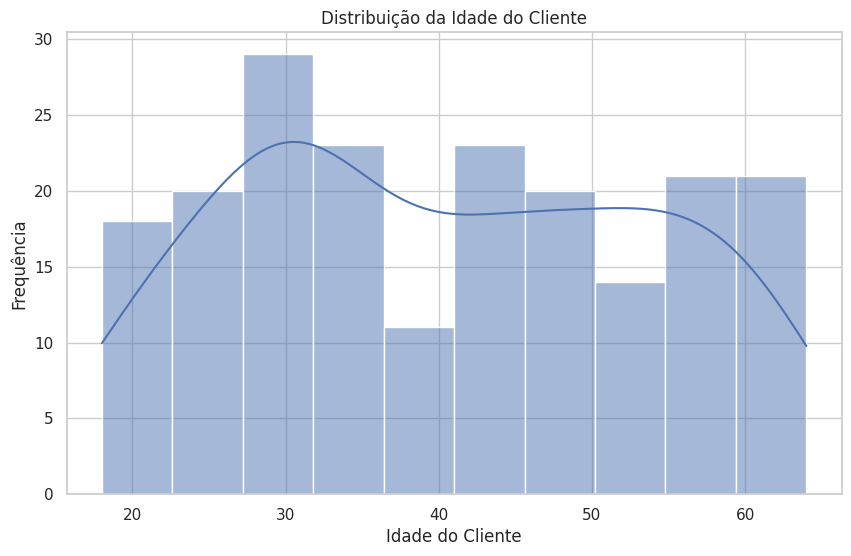

In [6]:
# 1. Crie um gráfico de Histograma com curva de densidade (sns.histplot com kde=True) para visualizar a distribuição da Idade_Cliente.
# 2. Adicione título e rótulos adequados aos eixos do gráfico.
plt.figure(figsize=(10, 6))
sns.histplot(data=df_ecommerce, x='Idade_Cliente', kde=True, bins=10)
plt.title('Distribuição da Idade do Cliente')
plt.xlabel('Idade do Cliente')
plt.ylabel('Frequência')
plt.show()